## UDU vs non-UDU: temporal change analysis

Compare LARIAC building change patterns between known UDU parcels and a matched control sample of single-family residences.

**Source**: `data/04_results/lariac_symdiff.gpkg` (output of `01_lariac_symdiff.ipynb`)

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

os.chdir('../..')

from src.geoadmin import load_neighborhoods, load_laraic


SYMDIFF_PATH = 'data/04_results/lariac_symdiff.gpkg'
MASTER_PATH  = 'data/processed/assessor_lariac.gpkg'
UDU_PATH     = 'data/01_raw/UDU Report 25.12.16.csv'

def normalize_ain(s):
    return str(s).strip().replace('-', '')

### 1. UDU count by neighborhood

In [2]:
udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = set(
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
print(f'{len(udu_ains):,} UDU AINs loaded')

184 UDU AINs loaded


In [3]:
from src.geoadmin import load_neighborhoods

hoods = load_neighborhoods().to_crs(4326)

udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = (
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
# load parcel geometries for all UDU AINs from master (2017 layer)
udu_parcels = gpd.read_file(
    'data/processed/assessor_lariac.gpkg', layer='2017',
    columns=['AIN', 'geometry']
)
udu_parcels['AIN'] = udu_parcels['AIN'].apply(normalize_ain)
udu_parcels = udu_parcels[udu_parcels['AIN'].isin(udu_ains)].to_crs(4326)

# spatial join parcel centroids → neighborhood
centroids = udu_parcels.set_geometry(udu_parcels.centroid)
joined = gpd.sjoin(centroids[['AIN', 'geometry']],
                   hoods[['name', 'geometry']],
                   how='left', predicate='within')

udu_by_hood = (
    joined.groupby('name').size()
    .reset_index(name='udu_count')
    .sort_values('udu_count', ascending=False)
    .reset_index(drop=True)
)
print(f"Matched {joined['name'].notna().sum()} / {len(joined)} UDU parcels to a neighborhood")
udu_by_hood[udu_by_hood['udu_count'] > 0]

Matched 183 / 183 UDU parcels to a neighborhood


/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_41828/2941173045.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = udu_parcels.set_geometry(udu_parcels.centroid)


,name,udu_count
0,Venice,12
1,Boyle Heights,8
2,Hollywood,7
3,Vermont Square,7
4,Florence,7
...,...,...
61,Del Rey,1
62,Carthay,1
63,Canoga Park,1
64,Broadway-Manchester,1


### Venice UDU parcels — LARIAC footprint overlay
Load LARIAC for all 3 years, dissolve to parcel-level footprint, and overlay on all 12 UDU parcels.

12 UDU AINs in Venice


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

  2014: 9058 AINs dissolved


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC5_Buildings_2017.gdb': 'LARIAC5_BUILDINGS_2017' (default), 'LARIAC4_BUILDINGS_DELETED_2017'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(pa

  2017: 8673 AINs dissolved


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC6_Buildings_2020.gdb': 'LARIAC6_BUILDINGS_2020' (default), 'LARIAC5_BUILDINGS_DELETED_2020'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(pa

  2020: 8665 AINs dissolved


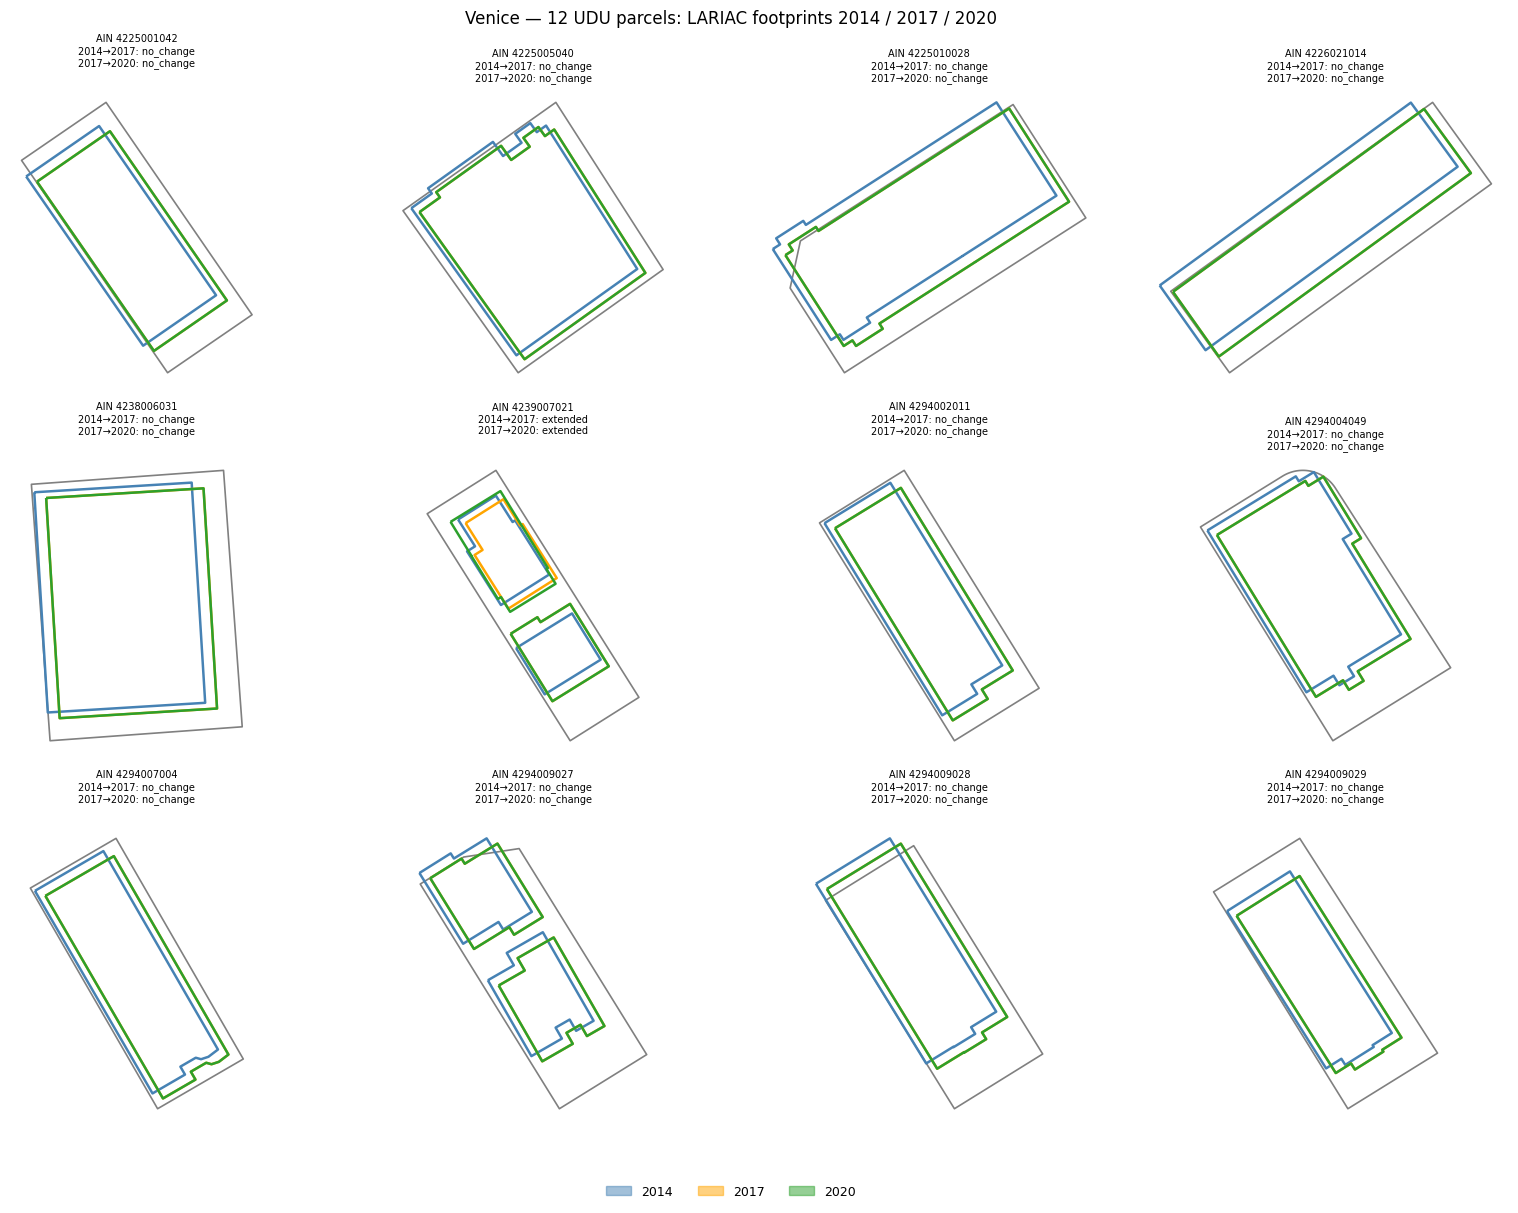

In [4]:
from shapely.affinity import translate
import matplotlib.patches as mpatches
from src.geoadmin import load_neighborhoods, load_laraic

VENICE = 'Venice'

# ── helpers (mirrors 01_lariac_symdiff) ───────────────────────────────────────
UTM_CRS_LOC          = 32611
NECK_THRESHOLD_M_LOC = 1.0

def _split(gdf, threshold=NECK_THRESHOLD_M_LOC):
    orig = gdf.crs
    g    = gdf.to_crs(UTM_CRS_LOC)
    min_area = 3.14159 * threshold ** 2
    rows = []
    for _, row in g.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty: continue
        eroded = geom.buffer(-threshold, join_style=2)
        if eroded.is_empty: rows.append(row); continue
        restored = eroded.buffer(threshold, join_style=2)
        if restored.geom_type == 'MultiPolygon':
            for part in restored.geoms:
                if part.area >= min_area:
                    r = row.copy(); r.geometry = part; rows.append(r)
        else:
            r = row.copy(); r.geometry = restored; rows.append(r)
    return gpd.GeoDataFrame(rows, crs=UTM_CRS_LOC).reset_index(drop=True).to_crs(orig)

def _dissolve(lar, parcel_ref):
    lar = lar.to_crs(parcel_ref.crs).copy()
    if 'AIN' in lar.columns and lar['AIN'].notna().any():
        lar['AIN'] = lar['AIN'].astype(str)
    else:
        joined  = gpd.sjoin(lar.set_geometry(lar.centroid),
                            parcel_ref[['AIN','geometry']], how='left')
        lar['AIN'] = joined['AIN'].values
    return (lar.dissolve(by='AIN')[['geometry']]
              .rename_geometry('footprint'))

# ── load Venice symdiff + UDU AINs ────────────────────────────────────────────
v_symdiff = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer=l, where=f"neighborhood = '{VENICE}'")
    for l in ['symdiff_2014_2017', 'symdiff_2017_2020']
], ignore_index=True)
v_symdiff['AIN'] = v_symdiff['AIN'].apply(normalize_ain)
v_symdiff['is_udu'] = v_symdiff['AIN'].isin(udu_ains)

venice_udu_ains = v_symdiff.loc[v_symdiff['is_udu'], 'AIN'].unique()
print(f"{len(venice_udu_ains)} UDU AINs in Venice")

# parcel boundaries from symdiff (first epoch)
parcel_ref_v = (v_symdiff[v_symdiff['epoch'] == '2014→2017'][['AIN','geometry']]
                .drop_duplicates('AIN').reset_index(drop=True))

# ── load + dissolve LARIAC for Venice, all 3 years ────────────────────────────
aoi_v = hoods[hoods['name'] == VENICE]
lar_fp = {}
for yr in [2014, 2017, 2020]:
    lar = load_laraic(aoi_v, yr)
    lar = lar[lar['CODE'] == 'Building'].copy().to_crs(parcel_ref_v.crs)
    lar_fp[yr] = _dissolve(_split(lar), parcel_ref_v)
    print(f"  {yr}: {len(lar_fp[yr])} AINs dissolved")

# ── plot ──────────────────────────────────────────────────────────────────────
YR_COLORS = {2014: 'steelblue', 2017: 'orange', 2020: '#2ca02c'}
n_udu  = len(venice_udu_ains)
n_cols = 4
n_rows = -(-n_udu // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, ain in zip(axes, venice_udu_ains):
    # parcel boundary
    parcel_geom = parcel_ref_v.loc[parcel_ref_v['AIN'] == ain, 'geometry']
    if not parcel_geom.empty:
        gpd.GeoSeries(parcel_geom.values, crs=parcel_ref_v.crs).plot(
            ax=ax, facecolor='none', edgecolor='gray', linewidth=1.2)

    # footprints for each year — boundary only for clarity
    for yr, color in YR_COLORS.items():
        d = lar_fp.get(yr)
        if d is not None and ain in d.index:
            gpd.GeoSeries([d.loc[ain, 'footprint']], crs=parcel_ref_v.crs).boundary.plot(
                ax=ax, edgecolor=color, linewidth=1.8)

    # subtitle: change type per epoch
    changes = (v_symdiff[v_symdiff['AIN'] == ain]
               .sort_values('epoch')[['epoch','change_type']]
               .apply(lambda r: f"{r['epoch']}: {r['change_type']}", axis=1)
               .tolist())
    ax.set_title(f'AIN {ain}\n' + '\n'.join(changes), fontsize=7)
    ax.axis('off')

for ax in axes[n_udu:]:
    ax.axis('off')

patches = [mpatches.Patch(color=c, alpha=0.5, label=str(yr))
           for yr, c in YR_COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle(f'Venice — {n_udu} UDU parcels: LARIAC footprints 2014 / 2017 / 2020',
             fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### 3. Load symdiff — all UDU parcels

In [6]:
ain_sql   = "','".join(sorted(udu_ains))
symdiff_udu = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer=layer, where=f"AIN IN ('{ain_sql}')")
    for layer in ['symdiff_2014_2017', 'symdiff_2017_2020']
], ignore_index=True)
symdiff_udu['AIN']    = symdiff_udu['AIN'].apply(normalize_ain)
symdiff_udu['group']  = 'UDU'
symdiff_udu['is_udu'] = symdiff_udu['AIN'].isin(udu_ains)

print(f"UDU: {symdiff_udu['AIN'].nunique()} AINs  |  {len(symdiff_udu):,} rows")
symdiff_udu.groupby(['epoch','change_type']).size().unstack(fill_value=0)

UDU: 180 AINs  |  362 rows


change_type,added_structure,extended,new_parcel,no_change,reduced,removed_structure
epoch,,,,,,
2014→2017,1,6,4,164,2,4
2017→2020,1,2,0,168,8,2


### 4. Load symdiff — SFR control sample (n=1,000)
Random sample of single-family residential parcels, excluding known UDU AINs.

In [7]:
# identify SFR AINs from master (2017 layer)
master = gpd.read_file(MASTER_PATH, layer='2017',
                       columns=['AIN', 'usetype'], read_geometry=False)
master['AIN'] = master['AIN'].apply(normalize_ain)

sfr_mask = master['usetype'].str.contains('Single', case=False, na=False)
sfr_ains = set(master.loc[sfr_mask & ~master['AIN'].isin(udu_ains), 'AIN'])
print(f"{len(sfr_ains):,} non-UDU SFR AINs available")

# sample 1,000
rng      = np.random.default_rng(42)
sfr_sample = set(rng.choice(sorted(sfr_ains), size=min(1000, len(sfr_ains)), replace=False))

ain_sql_sfr = "','".join(sorted(sfr_sample))
symdiff_sfr = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer=layer, where=f"AIN IN ('{ain_sql_sfr}')")
    for layer in ['symdiff_2014_2017', 'symdiff_2017_2020']
], ignore_index=True)
symdiff_sfr['AIN']   = symdiff_sfr['AIN'].apply(normalize_ain)
symdiff_sfr['group'] = 'SFR (non-UDU)'
symdiff_sfr['is_udu'] = symdiff_sfr['AIN'].isin(udu_ains)

print(f"SFR sample: {symdiff_sfr['AIN'].nunique()} AINs  |  {len(symdiff_sfr):,} rows")
symdiff_sfr.groupby(['epoch','change_type']).size().unstack(fill_value=0)

1,121,729 non-UDU SFR AINs available
SFR sample: 442 AINs  |  859 rows


change_type,added_structure,demolished,extended,new_parcel,no_change,reduced,removed_structure
epoch,,,,,,,
2014→2017,9,27,27,4,357,11,8
2017→2020,3,1,12,0,383,11,6


### 5. Change type breakdown: UDU vs SFR control
Proportion of each change class per group, per epoch.

Saved → notebooks/tasks/figures/udu_change_type_proportions.png


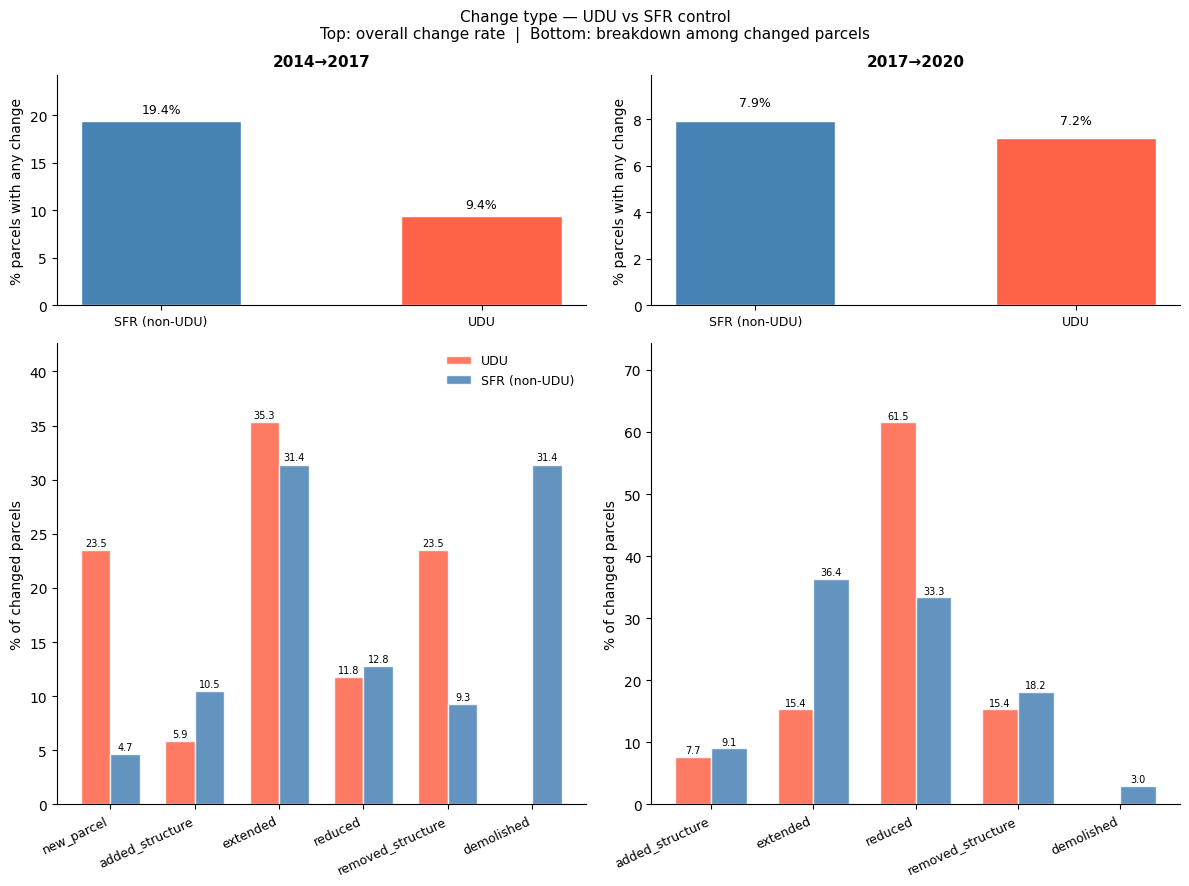

In [17]:
symdiff = pd.concat([symdiff_udu, symdiff_sfr], ignore_index=True)

CHANGE_TYPES = ['new_parcel', 'added_structure', 'extended',
                'reduced', 'removed_structure', 'demolished']
COLORS = {
    'UDU':           'tomato',
    'SFR (non-UDU)': 'steelblue',
}

epochs = sorted(symdiff['epoch'].unique())
fig, axes = plt.subplots(2, len(epochs), figsize=(6 * len(epochs), 9),
                         gridspec_kw={'height_ratios': [1, 2]})

for col, epoch in enumerate(epochs):
    sub = symdiff[symdiff['epoch'] == epoch].copy()
    sub['changed'] = sub['change_type'] != 'no_change'

    # ── row 0: overall change rate ────────────────────────────────────────────
    ax0 = axes[0, col]
    rates = sub.groupby('group')['changed'].mean() * 100
    bars = ax0.bar(rates.index, rates.values,
                   color=[COLORS[g] for g in rates.index],
                   width=0.5, edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax0.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax0.set_title(epoch, fontsize=11, fontweight='bold')
    ax0.set_ylabel('% parcels with any change')
    ax0.set_ylim(0, rates.max() * 1.25)
    ax0.set_xticks(range(len(rates)))
    ax0.set_xticklabels(rates.index, fontsize=9)
    ax0.spines[['top', 'right']].set_visible(False)

    # ── row 1: breakdown among changed parcels only ───────────────────────────
    ax1 = axes[1, col]
    changed = sub[sub['changed']]
    present = [c for c in CHANGE_TYPES if c in changed['change_type'].values]

    x = np.arange(len(present))
    width = 0.35
    for i, (group, color) in enumerate(COLORS.items()):
        g = changed[changed['group'] == group]
        total = len(g)
        vals = [100 * (g['change_type'] == ct).sum() / total if total else 0
                for ct in present]
        offset = (i - 0.5) * width
        bars2 = ax1.bar(x + offset, vals, width=width,
                        color=color, alpha=0.85, label=group, edgecolor='white')
        for bar, val in zip(bars2, vals):
            if val > 0.5:
                ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                         f'{val:.1f}', ha='center', va='bottom', fontsize=7)

    ax1.set_xticks(x)
    ax1.set_xticklabels(present, rotation=25, ha='right', fontsize=9)
    ax1.set_ylabel('% of changed parcels')
    ax1.set_ylim(0, ax1.get_ylim()[1] * 1.15)
    ax1.spines[['top', 'right']].set_visible(False)
    if col == 0:
        ax1.legend(fontsize=9, frameon=False)

plt.suptitle('Change type — UDU vs SFR control\n'
             'Top: overall change rate  |  Bottom: breakdown among changed parcels',
             fontsize=11)
plt.tight_layout()

OUT_FIG = 'notebooks/tasks/figures/udu_change_type_proportions.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


### Net area change distribution

is_udu     non-UDU  UDU
epoch                  
2014→2017       55   13
2017→2020       32   13


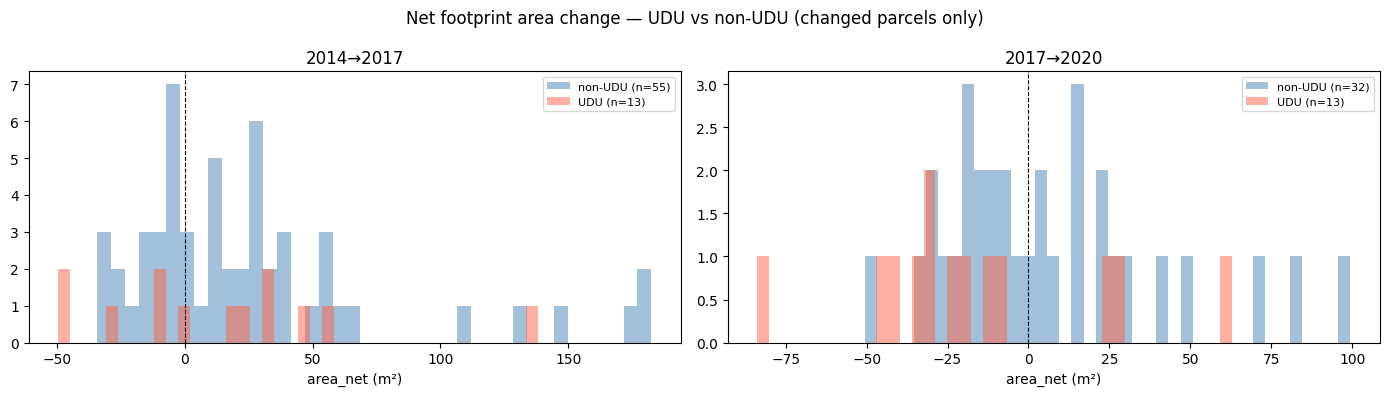

In [9]:
focus_types = ['added_structure', 'extended', 'reduced', 'removed_structure']
sub = symdiff[symdiff['change_type'].isin(focus_types)]

# diagnostic — show how many records per group
print(sub.groupby(['epoch', 'is_udu']).size().unstack(fill_value=0).rename(columns={False:'non-UDU', True:'UDU'}))

epochs = sorted(sub['epoch'].unique())
fig, axes = plt.subplots(1, len(epochs), figsize=(7 * len(epochs), 4), sharey=False)
if len(epochs) == 1:
    axes = [axes]

for ax, epoch in zip(axes, epochs):
    ep = sub[sub['epoch'] == epoch]
    has_data = False
    for flag, color, name in [(False, 'steelblue', 'non-UDU'), (True, 'tomato', 'UDU')]:
        vals = ep.loc[ep['is_udu'] == flag, 'area_net'].dropna()
        if len(vals) < 2:
            ax.text(0.5, 0.5, f'no {name} data', transform=ax.transAxes,
                    ha='center', va='center', color=color, fontsize=9)
            continue
        lo, hi = vals.quantile(0.02), vals.quantile(0.98)
        if lo == hi:
            lo, hi = vals.min(), vals.max()
        if lo == hi:   # all identical values — just mark with vline
            ax.axvline(lo, color=color, linewidth=2, label=f'{name} (n={len(vals)})')
            continue
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.5,
                color=color, label=f'{name} (n={len(vals)})')
        has_data = True
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('area_net (m²)')
    ax.legend(fontsize=8)

plt.suptitle('Net footprint area change — UDU vs non-UDU (changed parcels only)', fontsize=12)
plt.tight_layout()
plt.show()

### Building count delta

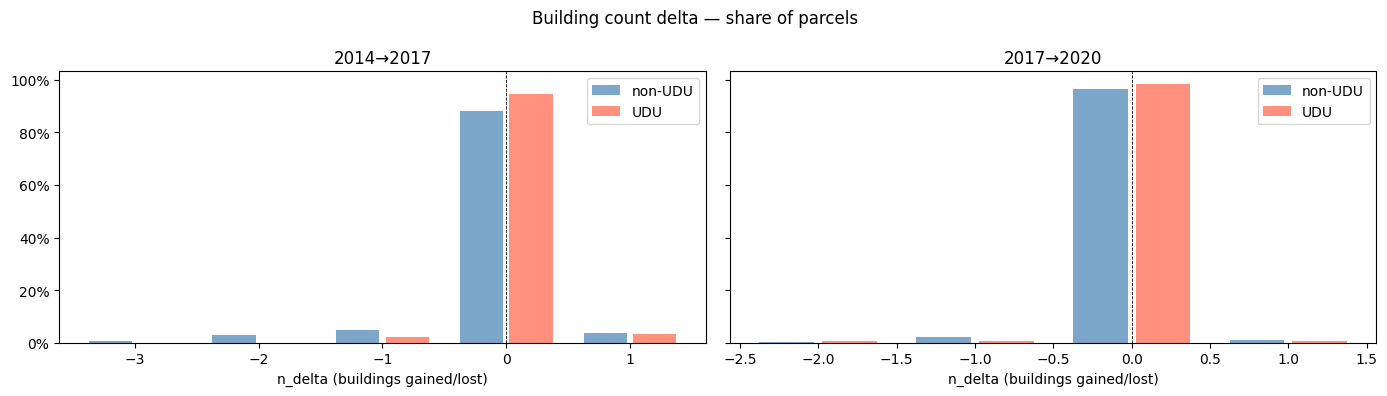

In [10]:
delta_counts = (
    symdiff
    .groupby(['epoch', 'is_udu', 'n_delta'])
    .size()
    .reset_index(name='count')
)
delta_counts['share'] = delta_counts.groupby(['epoch', 'is_udu'])['count'].transform(lambda x: x / x.sum())
delta_counts['group'] = delta_counts['is_udu'].map({True: 'UDU', False: 'non-UDU'})

epochs = sorted(delta_counts['epoch'].unique())
fig, axes = plt.subplots(1, len(epochs), figsize=(7 * len(epochs), 4), sharey=True)
if len(epochs) == 1:
    axes = [axes]

for ax, epoch in zip(axes, epochs):
    ep = delta_counts[delta_counts['epoch'] == epoch]
    for group, color in [('non-UDU', 'steelblue'), ('UDU', 'tomato')]:
        g = ep[ep['group'] == group].sort_values('n_delta')
        ax.bar(g['n_delta'] + (0.2 if group == 'UDU' else -0.2),
               g['share'], width=0.35, alpha=0.7, color=color, label=group)
    ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('n_delta (buildings gained/lost)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend()

plt.suptitle('Building count delta — share of parcels', fontsize=12)
plt.tight_layout()
plt.show()

### Summary table

In [11]:
summary = (
    symdiff
    .groupby(['epoch', 'is_udu', 'change_type'])
    .size()
    .reset_index(name='n')
)
summary['pct'] = summary.groupby(['epoch', 'is_udu'])['n'].transform(lambda x: 100 * x / x.sum())
(summary
 .pivot_table(index=['epoch', 'change_type'], columns='is_udu', values='pct')
 .rename(columns={False: 'non-UDU %', True: 'UDU %'})
 .round(1)
)

is_udu                       non-UDU %  UDU %
epoch     change_type                        
2014→2017 added_structure          2.0    0.6
          demolished               6.1    NaN
          extended                 6.1    3.3
          new_parcel               0.9    2.2
          no_change               80.6   90.6
          reduced                  2.5    1.1
          removed_structure        1.8    2.2
2017→2020 added_structure          0.7    0.6
          demolished               0.2    NaN
          extended                 2.9    1.1
          no_change               92.1   92.8
          reduced                  2.6    4.4
          removed_structure        1.4    1.1

10 reduced UDU parcels across 7 neighborhoods
neighborhood
Boyle Heights      2
Central-Alameda    2
Hollywood          2
Van Nuys           1
Vermont Vista      1
East Hollywood     1
Fairfax            1
Name: count, dtype: int64


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

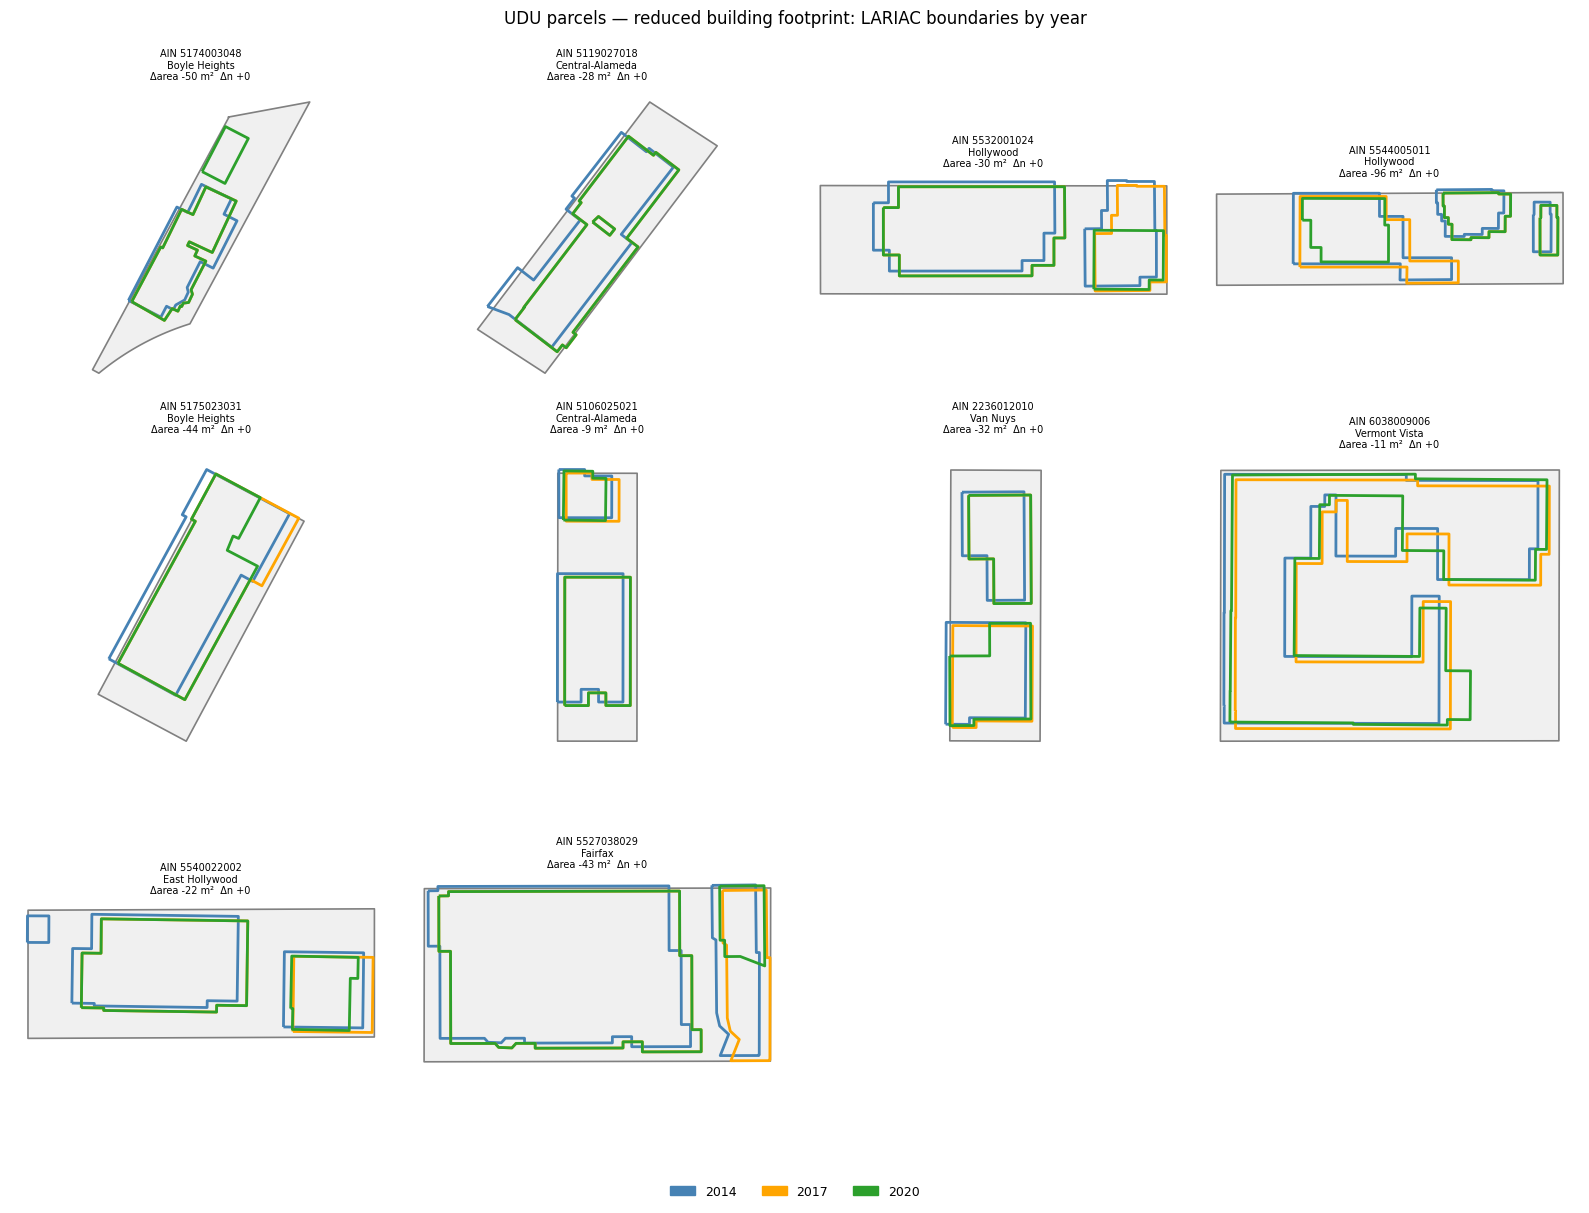

In [13]:
# All UDU parcels classified as 'reduced' in either epoch
reduced = (symdiff_udu[symdiff_udu['change_type'] == 'reduced']
           [['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta', 'geometry']]
           .drop_duplicates('AIN')
           .reset_index(drop=True))

print(f"{len(reduced)} reduced UDU parcels across {reduced['neighborhood'].nunique()} neighborhoods")
print(reduced['neighborhood'].value_counts())

YR_COLORS = {2014: 'steelblue', 2017: 'orange', 2020: '#2ca02c'}
n = len(reduced)
n_cols = min(4, n)
n_rows = -(-n // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, reduced.iterrows()):
    ain  = row['AIN']
    hood = row['neighborhood']
    aoi  = hoods[hoods['name'] == hood]

    # parcel boundary (gray)
    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=reduced.crs).plot(
            ax=ax, facecolor='#f0f0f0', edgecolor='gray', linewidth=1.2)

    # LARIAC boundaries per year
    for yr, color in YR_COLORS.items():
        try:
            lar = load_laraic(aoi, yr)
            lar = lar[lar['CODE'] == 'Building'].copy().to_crs(reduced.crs)
            d   = _dissolve(_split(lar), reduced[['AIN', 'geometry']])
            if ain in d.index:
                gpd.GeoSeries([d.loc[ain, 'footprint']], crs=reduced.crs).boundary.plot(
                    ax=ax, edgecolor=color, linewidth=2)
        except Exception:
            pass

    ax.set_title(
        f'AIN {ain}\n{hood}\nΔarea {row["area_net"]:+.0f} m²  Δn {row["n_delta"]:+.0f}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [mpatches.Patch(color=c, label=str(yr)) for yr, c in YR_COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — reduced building footprint: LARIAC boundaries by year', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

Saved → notebooks/tasks/figures/udu_reduced_footprint_diff.png


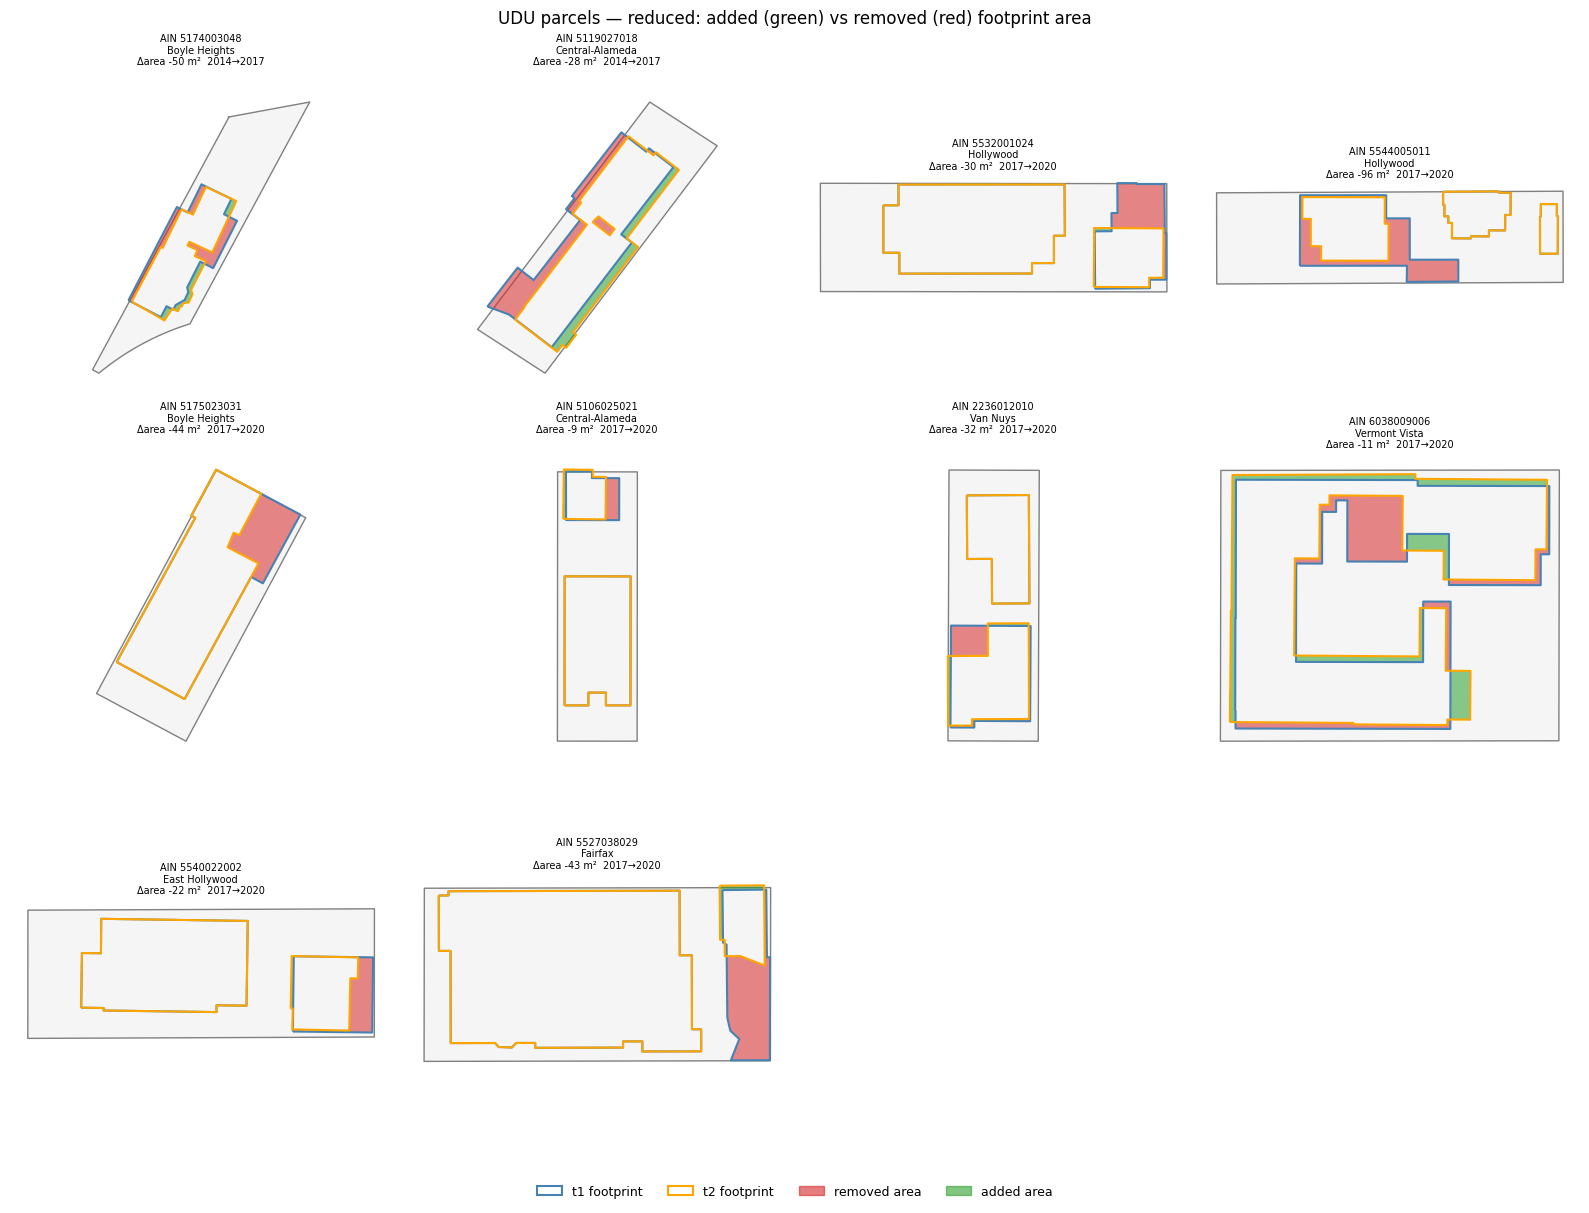

In [18]:
# For each reduced UDU parcel: compute removed area (t1 − t2) and added area (t2 − t1)
# Groups by neighborhood so LARIAC is only loaded once per hood×year pair

from shapely.ops import unary_union

def footprints_for_hood(hood_name, yr, parcel_crs):
    """Load + split + dissolve LARIAC for one neighborhood×year → {AIN: footprint geom}."""
    aoi = hoods[hoods['name'] == hood_name]
    try:
        lar = load_laraic(aoi, yr)
        lar = lar[lar['CODE'] == 'Building'].copy().to_crs(parcel_crs)
        d   = _dissolve(_split(lar), reduced[['AIN', 'geometry']])
        return d['footprint'].to_dict()
    except Exception:
        return {}

# parse years from epoch string
reduced['yr1'] = reduced['epoch'].str.split('→').str[0].astype(int)
reduced['yr2'] = reduced['epoch'].str.split('→').str[1].astype(int)

n = len(reduced)
n_cols = min(4, n)
n_rows = -(-n // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

# cache LARIAC loads per (hood, year)
fp_cache = {}

for ax, (_, row) in zip(axes, reduced.iterrows()):
    ain  = row['AIN']
    hood = row['neighborhood']
    yr1, yr2 = row['yr1'], row['yr2']
    crs = reduced.crs

    for yr in (yr1, yr2):
        if (hood, yr) not in fp_cache:
            fp_cache[(hood, yr)] = footprints_for_hood(hood, yr, crs)

    fp1 = fp_cache[(hood, yr1)].get(ain)
    fp2 = fp_cache[(hood, yr2)].get(ain)

    # parcel background
    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=crs).plot(
            ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

    # footprint outlines
    for fp, color, lw in [(fp1, 'steelblue', 1.5), (fp2, 'orange', 1.5)]:
        if fp and not fp.is_empty:
            gpd.GeoSeries([fp], crs=crs).boundary.plot(ax=ax, edgecolor=color, linewidth=lw)

    # highlight changed areas
    if fp1 and fp2 and not fp1.is_empty and not fp2.is_empty:
        removed = fp1.difference(fp2)   # was there, now gone  → red
        added   = fp2.difference(fp1)   # wasn't there, now is → green
        if removed and not removed.is_empty:
            gpd.GeoSeries([removed], crs=crs).plot(ax=ax, facecolor='#d62728', alpha=0.55, edgecolor='none')
        if added and not added.is_empty:
            gpd.GeoSeries([added],   crs=crs).plot(ax=ax, facecolor='#2ca02c', alpha=0.55, edgecolor='none')

    ax.set_title(
        f'AIN {ain}\n{hood}\nΔarea {row["area_net"]:+.0f} m²  {yr1}→{yr2}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [
    mpatches.Patch(edgecolor='steelblue', facecolor='none', linewidth=1.5, label='t1 footprint'),
    mpatches.Patch(edgecolor='orange',    facecolor='none', linewidth=1.5, label='t2 footprint'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='removed area'),
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='added area'),
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — reduced: added (green) vs removed (red) footprint area', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT_FIG = 'notebooks/tasks/figures/udu_reduced_footprint_diff.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


6 removed_structure UDU parcels
neighborhood
Hollywood          1
San Pedro          1
Echo Park          1
East Hollywood     1
Central-Alameda    1
Vermont Vista      1
Name: count, dtype: int64


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

Saved → notebooks/tasks/figures/udu_removed_structure.png


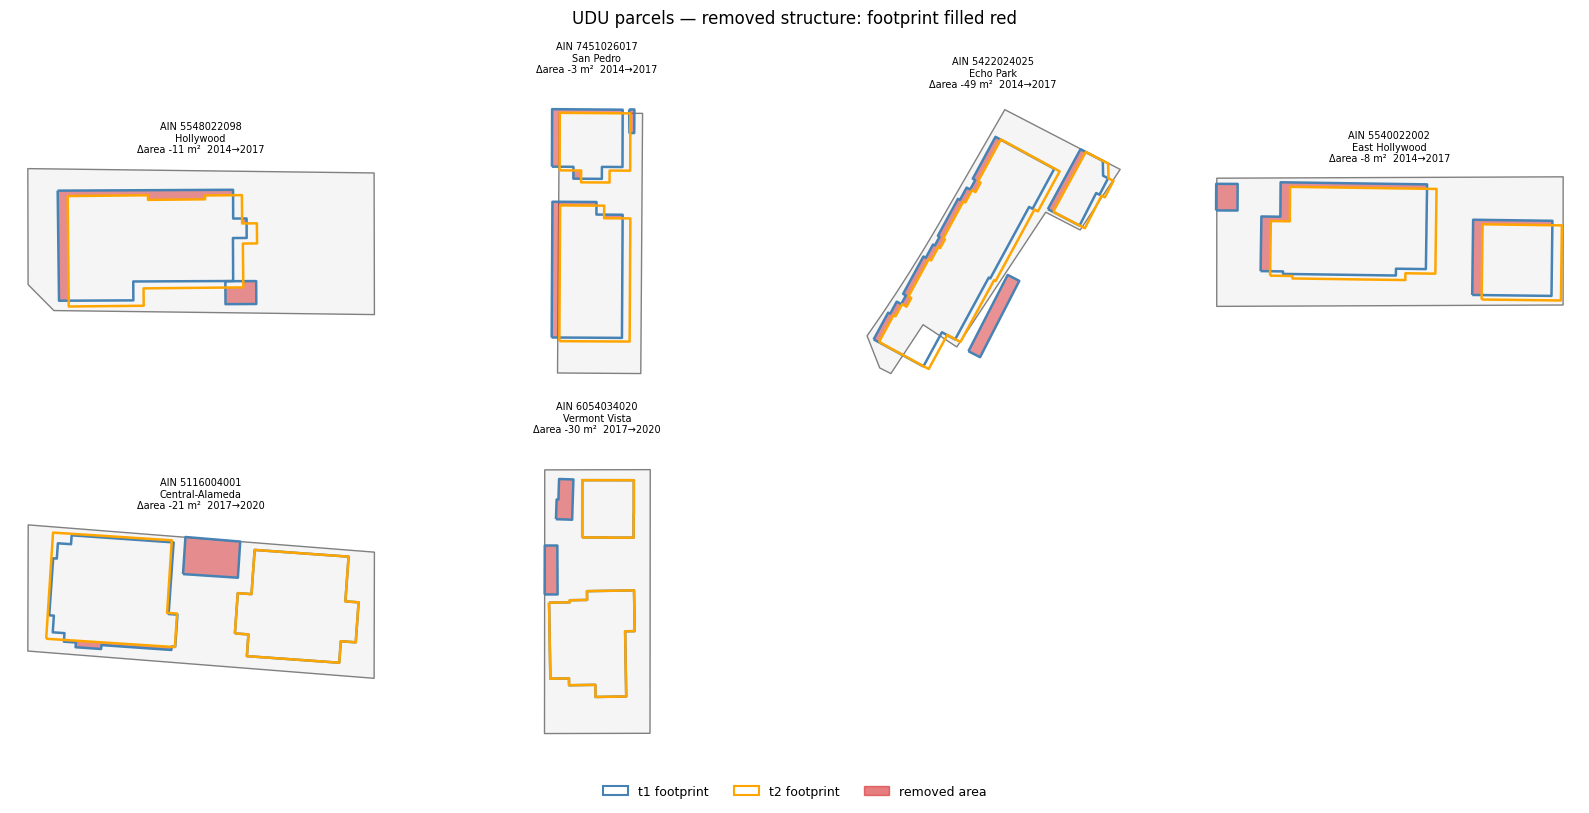

In [21]:
removed_struct = (symdiff_udu[symdiff_udu['change_type'] == 'removed_structure']
                  [['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta', 'geometry']]
                  .drop_duplicates('AIN')
                  .reset_index(drop=True))

removed_struct['yr1'] = removed_struct['epoch'].str.split('→').str[0].astype(int)
removed_struct['yr2'] = removed_struct['epoch'].str.split('→').str[1].astype(int)

print(f"{len(removed_struct)} removed_structure UDU parcels")
print(removed_struct['neighborhood'].value_counts())

n = len(removed_struct)
n_cols = min(4, n)
n_rows = -(-n // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

fp_cache_rs = {}

def _fp_for_hood(df_ref, hood_name, yr, parcel_crs):
    aoi = hoods[hoods['name'] == hood_name]
    try:
        lar = load_laraic(aoi, yr)
        lar = lar[lar['CODE'] == 'Building'].copy().to_crs(parcel_crs)
        d   = _dissolve(_split(lar), df_ref[['AIN', 'geometry']])
        return d['footprint'].to_dict()
    except Exception:
        return {}

for ax, (_, row) in zip(axes, removed_struct.iterrows()):
    ain       = row['AIN']
    hood      = row['neighborhood']
    yr1, yr2  = row['yr1'], row['yr2']
    crs       = removed_struct.crs

    for yr in (yr1, yr2):
        if (hood, yr) not in fp_cache_rs:
            fp_cache_rs[(hood, yr)] = _fp_for_hood(removed_struct, hood, yr, crs)

    fp1 = fp_cache_rs[(hood, yr1)].get(ain)
    fp2 = fp_cache_rs[(hood, yr2)].get(ain)

    # parcel background
    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=crs).plot(
            ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

    # removed area = everything in t1 not in t2 → red fill
    if fp1 and not fp1.is_empty:
        removed_area = fp1.difference(fp2) if (fp2 and not fp2.is_empty) else fp1
        if removed_area and not removed_area.is_empty:
            gpd.GeoSeries([removed_area], crs=crs).plot(
                ax=ax, facecolor='#d62728', alpha=0.5, edgecolor='none')

    # t1 boundary (blue) and t2 boundary (orange) for context
    for fp, color in [(fp1, 'steelblue'), (fp2, 'orange')]:
        if fp and not fp.is_empty:
            gpd.GeoSeries([fp], crs=crs).boundary.plot(
                ax=ax, edgecolor=color, linewidth=1.8)

    ax.set_title(
        f'AIN {ain}\n{hood}\nΔarea {row["area_net"]:+.0f} m²  {yr1}→{yr2}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [
    mpatches.Patch(edgecolor='steelblue', facecolor='none', linewidth=1.5, label='t1 footprint'),
    mpatches.Patch(edgecolor='orange',    facecolor='none', linewidth=1.5, label='t2 footprint'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='removed area'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — removed structure: footprint filled red', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT_FIG = 'notebooks/tasks/figures/udu_removed_structure.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()

7 extended UDU parcels
neighborhood
North Hollywood    1
Venice             1
Glassell Park      1
Florence           1
Exposition Park    1
Vermont-Slauson    1
Echo Park          1
Name: count, dtype: int64


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

Saved → notebooks/tasks/figures/udu_extended.png


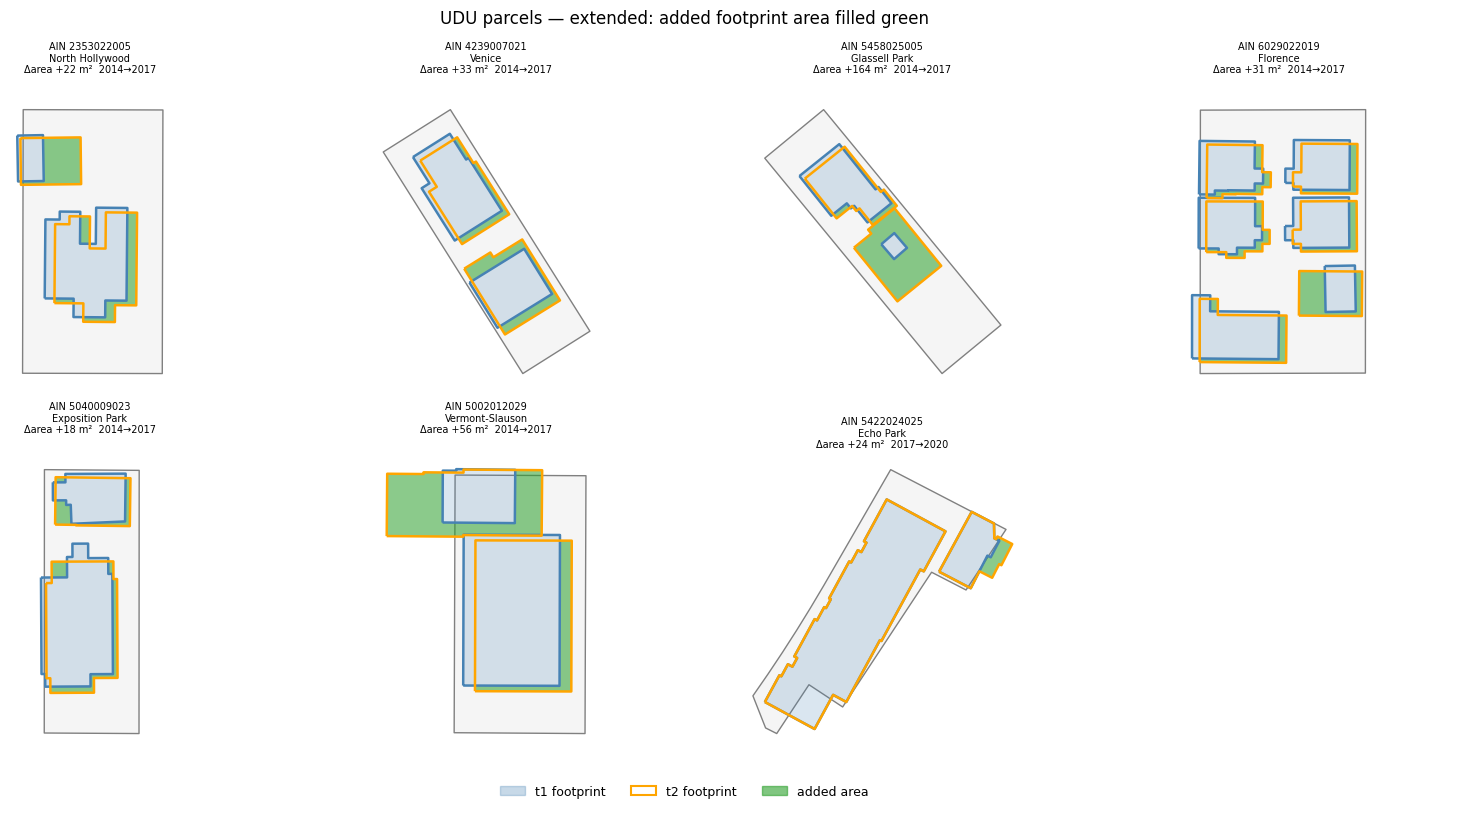

In [22]:
extended_udu = (symdiff_udu[symdiff_udu['change_type'] == 'extended']
                [['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta', 'geometry']]
                .drop_duplicates('AIN')
                .reset_index(drop=True))

extended_udu['yr1'] = extended_udu['epoch'].str.split('→').str[0].astype(int)
extended_udu['yr2'] = extended_udu['epoch'].str.split('→').str[1].astype(int)

print(f"{len(extended_udu)} extended UDU parcels")
print(extended_udu['neighborhood'].value_counts())

n = len(extended_udu)
n_cols = min(4, n)
n_rows = -(-n // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

fp_cache_ex = {}

for ax, (_, row) in zip(axes, extended_udu.iterrows()):
    ain       = row['AIN']
    hood      = row['neighborhood']
    yr1, yr2  = row['yr1'], row['yr2']
    crs       = extended_udu.crs

    for yr in (yr1, yr2):
        if (hood, yr) not in fp_cache_ex:
            fp_cache_ex[(hood, yr)] = _fp_for_hood(extended_udu, hood, yr, crs)

    fp1 = fp_cache_ex[(hood, yr1)].get(ain)
    fp2 = fp_cache_ex[(hood, yr2)].get(ain)

    # parcel background
    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=crs).plot(
            ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

    # existing footprint → light blue fill
    if fp1 and not fp1.is_empty:
        gpd.GeoSeries([fp1], crs=crs).plot(
            ax=ax, facecolor='steelblue', alpha=0.2, edgecolor='none')

    # added area = fp2 − fp1 → green fill
    if fp1 and fp2 and not fp1.is_empty and not fp2.is_empty:
        added_area = fp2.difference(fp1)
        if added_area and not added_area.is_empty:
            gpd.GeoSeries([added_area], crs=crs).plot(
                ax=ax, facecolor='#2ca02c', alpha=0.55, edgecolor='none')

    # t1 boundary (blue) and t2 boundary (orange)
    for fp, color in [(fp1, 'steelblue'), (fp2, 'orange')]:
        if fp and not fp.is_empty:
            gpd.GeoSeries([fp], crs=crs).boundary.plot(
                ax=ax, edgecolor=color, linewidth=1.8)

    ax.set_title(
        f'AIN {ain}\n{hood}\nΔarea {row["area_net"]:+.0f} m²  {yr1}→{yr2}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [
    mpatches.Patch(color='steelblue', alpha=0.3, label='t1 footprint'),
    mpatches.Patch(edgecolor='orange', facecolor='none', linewidth=1.5, label='t2 footprint'),
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='added area'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — extended: added footprint area filled green', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT_FIG = 'notebooks/tasks/figures/udu_extended.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


### Shadow additions — SFR parcels with footprint growth but no assessor update
Positive LARIAC area change (`added_structure`, `extended`, `new_parcel`, `area_net > 0`) but `assr_sqftmain` (assessor recorded sq ft) unchanged between epochs → candidate unpermitted addition.

55 positive-change SFR rows across 52 AINs
change_type  added_structure  extended  new_parcel
epoch                                             
2014→2017                  9        27           4
2017→2020                  3        12           0

Shadow additions: 46 / 55 (83.6%) positive-change SFR parcels
shadow     False  True 
epoch                  
2014→2017      4     36
2017→2020      5     10
Saved → notebooks/tasks/figures/sfr_shadow_additions.png


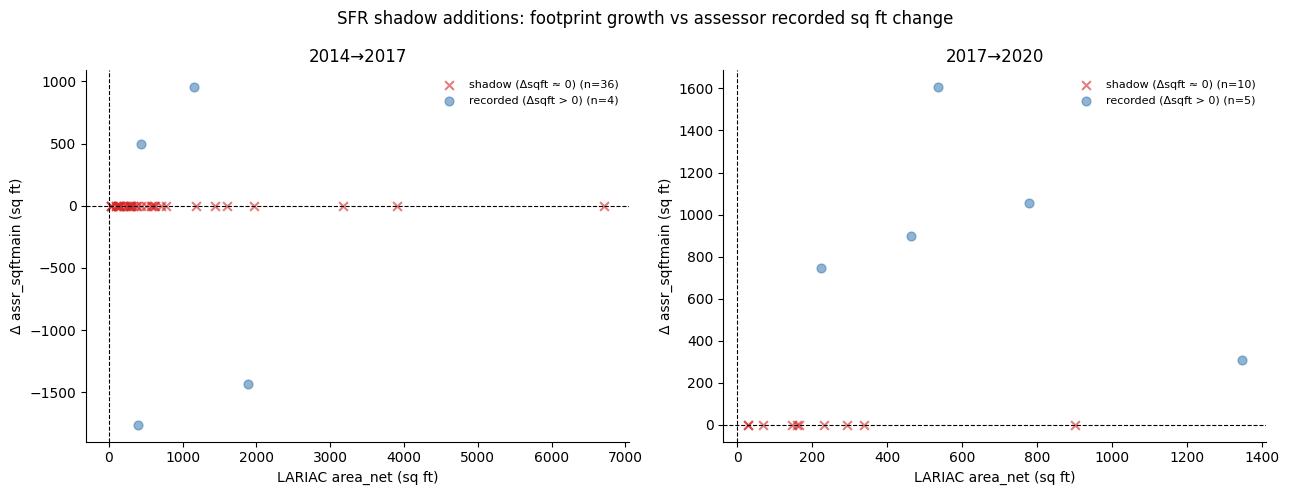

n  median_area_net_sqft
epoch     shadow change_type                              
2014→2017 False  extended          4                 795.8
          True   added_structure   9                 507.3
                 extended         23                 237.0
                 new_parcel        4                2180.2
2017→2020 False  added_structure   1                1346.1
                 extended          4                 500.1
          True   added_structure   2                 619.6
                 extended          8                 152.9

In [27]:
EPOCH_YRS  = {'2014→2017': (2014, 2017), '2017→2020': (2017, 2020)}
POS_TYPES  = ['added_structure', 'extended', 'new_parcel']
M2_TO_SQFT = 10.7639

# positive-change SFR rows
sfr_pos = (symdiff_sfr[
    symdiff_sfr['change_type'].isin(POS_TYPES) & (symdiff_sfr['area_net'] > 0)
][['AIN', 'epoch', 'change_type', 'area_net', 'n_delta']]
.copy().reset_index(drop=True))

print(f"{len(sfr_pos)} positive-change SFR rows across {sfr_pos['AIN'].nunique()} AINs")
print(sfr_pos.groupby(['epoch', 'change_type']).size().unstack(fill_value=0))

# ── load assr_sqftmain for t1 and t2 per epoch ───────────────────────────────
def load_assr_sqft(ains, layer_yr):
    ain_sql = "','".join(sorted(ains))
    df = gpd.read_file(
        MASTER_PATH, layer=str(layer_yr),
        columns=['AIN', 'assr_sqftmain'],
        where=f"AIN IN ('{ain_sql}')",
        read_geometry=False,
    )
    df['AIN'] = df['AIN'].apply(normalize_ain)
    return df.set_index('AIN')['assr_sqftmain']

records = []
for epoch, (yr1, yr2) in EPOCH_YRS.items():
    sub = sfr_pos[sfr_pos['epoch'] == epoch]
    if sub.empty:
        continue
    ains = set(sub['AIN'])
    sqft1 = load_assr_sqft(ains, yr1)
    sqft2 = load_assr_sqft(ains, yr2)

    for _, row in sub.iterrows():
        ain = row['AIN']
        s1  = sqft1.get(ain, np.nan)
        s2  = sqft2.get(ain, np.nan)
        records.append({
            **row.to_dict(),
            'area_net_sqft':   row['area_net'] * M2_TO_SQFT,
            'assr_sqft_t1':    s1,
            'assr_sqft_t2':    s2,
            'delta_assr_sqft': (s2 - s1) if pd.notna(s1) and pd.notna(s2) else np.nan,
        })

shadow_df = pd.DataFrame(records)

# shadow flag: footprint grew but assessor sq ft didn't increase
SQFT_THRESHOLD = 10   # sq ft — noise tolerance
shadow_df['shadow'] = (
    shadow_df['delta_assr_sqft'].fillna(0).abs() < SQFT_THRESHOLD
)

n_shadow = shadow_df['shadow'].sum()
n_total  = len(shadow_df)
print(f"\nShadow additions: {n_shadow} / {n_total} "
      f"({100*n_shadow/n_total:.1f}%) positive-change SFR parcels")
print(shadow_df.groupby(['epoch', 'shadow']).size().unstack(fill_value=0))

# ── scatter: area_net_sqft vs delta_assr_sqft (both in sq ft) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, epoch in zip(axes, sorted(shadow_df['epoch'].unique())):
    ep = shadow_df[shadow_df['epoch'] == epoch]
    for is_shadow, color, label, marker in [
        (True,  '#d62728', 'shadow (Δsqft ≈ 0)', 'x'),
        (False, 'steelblue', 'recorded (Δsqft > 0)', 'o'),
    ]:
        g = ep[ep['shadow'] == is_shadow]
        ax.scatter(
            g['area_net_sqft'],
            g['delta_assr_sqft'].fillna(0),
            c=color, alpha=0.6, s=40,
            marker=marker, label=f'{label} (n={len(g)})',
        )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('LARIAC area_net (sq ft)')
    ax.set_ylabel('Δ assr_sqftmain (sq ft)')
    ax.set_title(epoch)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('SFR shadow additions: footprint growth vs assessor recorded sq ft change',
             fontsize=12)
plt.tight_layout()

OUT_FIG = 'notebooks/tasks/figures/sfr_shadow_additions.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
(shadow_df
 .groupby(['epoch', 'shadow', 'change_type'])
 .agg(n=('AIN', 'count'), median_area_net_sqft=('area_net_sqft', 'median'))
 .round(1)
)

### Shadow additions — example parcels by epoch × shadow flag
Green fill = added footprint area (fp2 − fp1). Blue outline = t1, orange outline = t2.

ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

Saved → notebooks/tasks/figures/sfr_shadow_examples.png


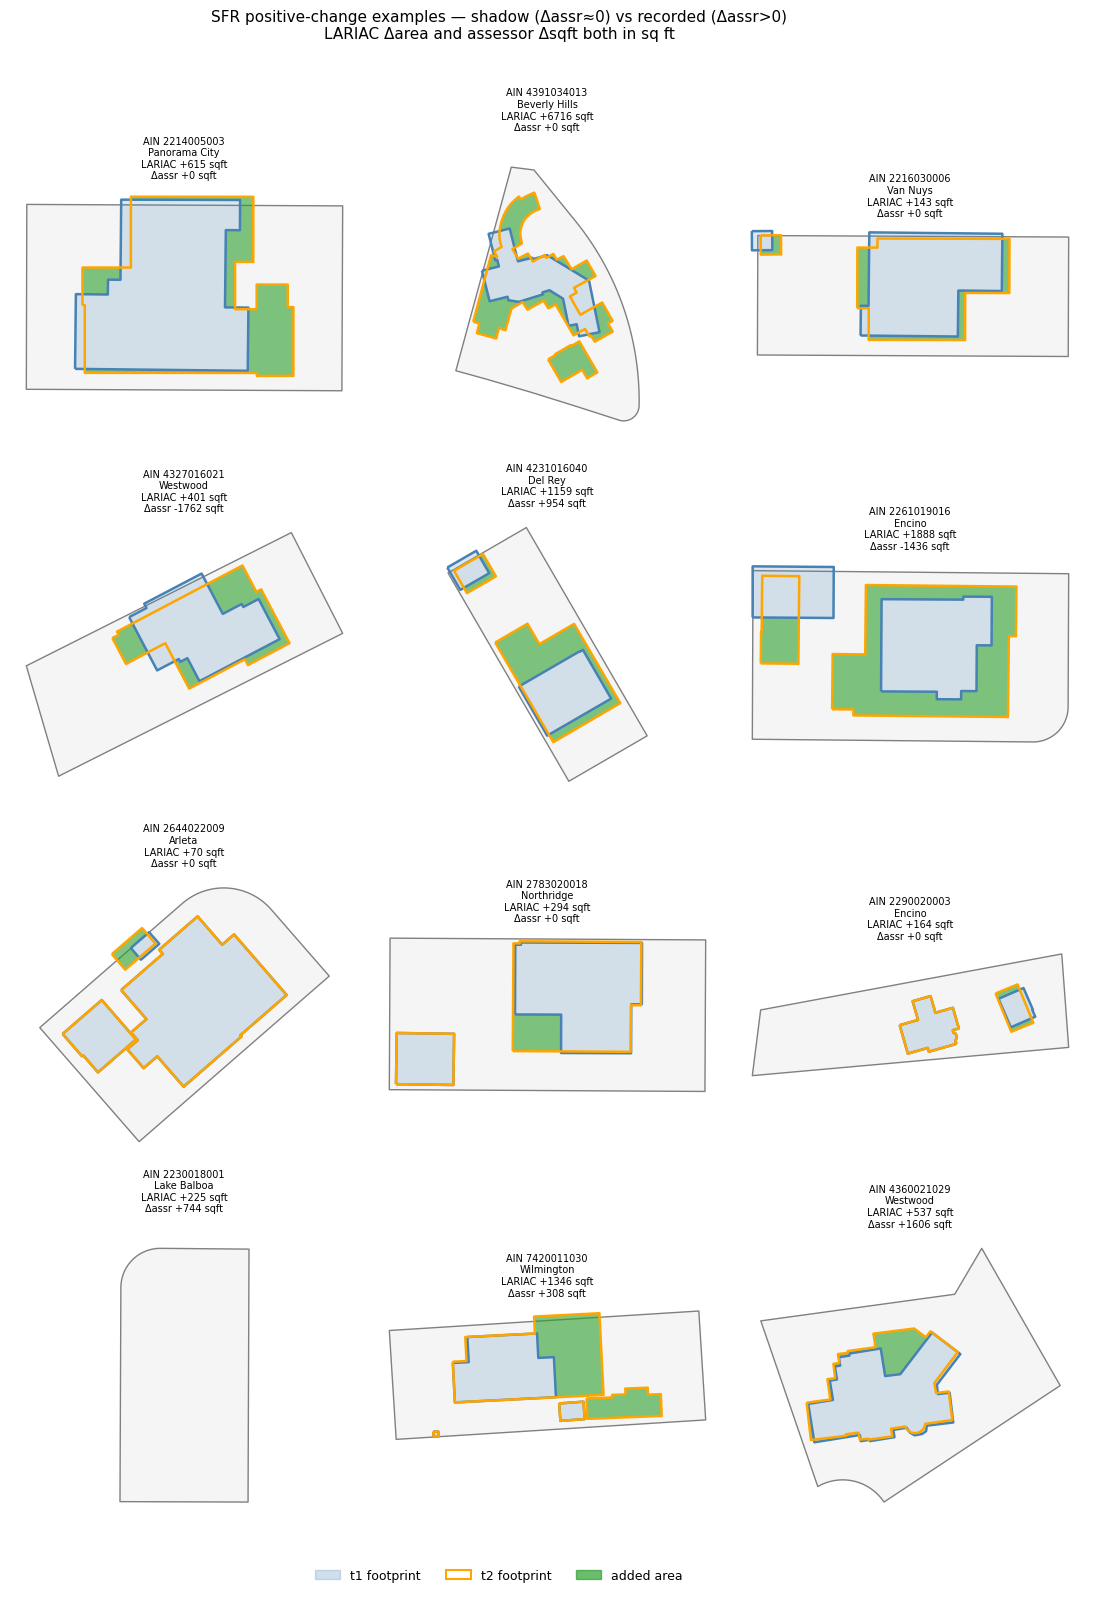

In [28]:
N_EXAMPLES = 3
rng_ex = np.random.default_rng(7)

# join shadow_df back to symdiff_sfr for geometry + neighborhood
shadow_geo = shadow_df.merge(
    symdiff_sfr[['AIN', 'epoch', 'neighborhood', 'geometry']],
    on=['AIN', 'epoch'], how='left'
)
shadow_geo = gpd.GeoDataFrame(shadow_geo, geometry='geometry', crs=symdiff_sfr.crs)

# ensure sqft column exists (guard against stale kernel state)
if 'area_net_sqft' not in shadow_geo.columns:
    shadow_geo['area_net_sqft'] = shadow_geo['area_net'] * 10.7639

COMBOS = [
    ('2014→2017', True,  'shadow'),
    ('2014→2017', False, 'recorded'),
    ('2017→2020', True,  'shadow'),
    ('2017→2020', False, 'recorded'),
]

n_rows = len(COMBOS)
n_cols = N_EXAMPLES
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

fp_cache_sh = {}

for row_i, (epoch, is_shadow, label) in enumerate(COMBOS):
    pool = shadow_geo[(shadow_geo['epoch'] == epoch) & (shadow_geo['shadow'] == is_shadow)]
    pool = pool.dropna(subset=['neighborhood', 'geometry'])
    idx  = rng_ex.choice(len(pool), size=min(N_EXAMPLES, len(pool)), replace=False)
    sample = pool.iloc[idx].reset_index(drop=True)

    yr1, yr2 = EPOCH_YRS[epoch]

    for col_i in range(n_cols):
        ax = axes[row_i, col_i]
        ax.axis('off')

        if col_i >= len(sample):
            continue

        row = sample.iloc[col_i]
        ain  = row['AIN']
        hood = row['neighborhood']
        crs  = shadow_geo.crs

        for yr in (yr1, yr2):
            if (hood, yr) not in fp_cache_sh:
                fp_cache_sh[(hood, yr)] = _fp_for_hood(shadow_geo, hood, yr, crs)

        fp1 = fp_cache_sh[(hood, yr1)].get(ain)
        fp2 = fp_cache_sh[(hood, yr2)].get(ain)

        # parcel background
        if row.geometry and not row.geometry.is_empty:
            gpd.GeoSeries([row.geometry], crs=crs).plot(
                ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

        # t1 fill (light blue)
        if fp1 and not fp1.is_empty:
            gpd.GeoSeries([fp1], crs=crs).plot(
                ax=ax, facecolor='steelblue', alpha=0.2, edgecolor='none')

        # added area = fp2 − fp1 → green fill
        if fp1 and fp2 and not fp1.is_empty and not fp2.is_empty:
            added_area = fp2.difference(fp1)
            if added_area and not added_area.is_empty:
                gpd.GeoSeries([added_area], crs=crs).plot(
                    ax=ax, facecolor='#2ca02c', alpha=0.6, edgecolor='none')

        # boundaries
        for fp, color in [(fp1, 'steelblue'), (fp2, 'orange')]:
            if fp and not fp.is_empty:
                gpd.GeoSeries([fp], crs=crs).boundary.plot(
                    ax=ax, edgecolor=color, linewidth=1.8)

        delta_s = row['delta_assr_sqft']
        delta_s_str = f'Δassr {delta_s:+.0f} sqft' if pd.notna(delta_s) else 'Δassr n/a'
        ax.set_title(
            f'AIN {ain}\n{hood}\n'
            f'LARIAC {row["area_net_sqft"]:+.0f} sqft\n{delta_s_str}',
            fontsize=7
        )
        ax.axis('off')

    # row label on left edge
    axes[row_i, 0].set_ylabel(
        f'{epoch}\n{"shadow" if is_shadow else "recorded"}',
        fontsize=9, rotation=0, labelpad=80, va='center'
    )

patches = [
    mpatches.Patch(color='steelblue', alpha=0.25, label='t1 footprint'),
    mpatches.Patch(edgecolor='orange', facecolor='none', linewidth=1.5, label='t2 footprint'),
    mpatches.Patch(color='#2ca02c', alpha=0.7, label='added area'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
plt.suptitle('SFR positive-change examples — shadow (Δassr≈0) vs recorded (Δassr>0)\n'
             'LARIAC Δarea and assessor Δsqft both in sq ft',
             fontsize=11)
plt.tight_layout(rect=[0.08, 0.03, 1, 0.97])

OUT_FIG = 'notebooks/tasks/figures/sfr_shadow_examples.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()